# Evaluation Results Analysis

This notebook loads the accumulated evaluation CSV and generates plots comparing all methods for BER, FER, and average messages.

## 1. Import Required Libraries
Import pandas, matplotlib, seaborn, and any other required libraries for data analysis and plotting.

In [1]:
import os
from glob import glob

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")


## 2. Load Evaluation Results
Load the accumulated CSV file (e.g., 'wran_full_accumulated.csv') containing evaluation results for all methods.

In [2]:
# Load and combine quick + full/legacy/local evaluation data when available
quick_pattern = "results_mi_quick_fe60_mf3000/wran_mi_quick_*.csv"

# New local or full-eval locations
full_accum_candidates = [
    "results_full_fe300_mf10000/wran_full_accumulated.csv",
    "wran_full_accumulated.csv",
]
full_run_pattern = "results_full_fe300_mf10000/wran_full_*.csv"
local_eval_candidates = [
    "results/eval_local_tabular_base_20260423.csv",
    "results/latest_berfer.csv",
    "results/eval_final_berfer_20260325_021320.csv",
    "results/eval_periodic_berfer_20260325_002118.csv",
    "results/eval_reldec_2_3_4_5_5p5.csv",
]

# Legacy/alternate locations already present in this repo
legacy_exact_files = [
    "results/eval_deep_z2_resume_live.csv",
    "results/eval_deep_z2_10k.csv",
    "results/eval_deep_z2_resume_live_z1_only.csv",
    "results/eval_deep_z2_10k_z1_only.csv",
    "results/latest_messages.csv",
    "results/eval_final_messages_20260325_021320.csv",
    "results/eval_periodic_messages_20260325_002118.csv",
]
legacy_glob_patterns = [
    "results/eval_*berfer*.csv",
    "../../../../results/eval_augmented_*.csv",
    "../../../../results/eval_global_mdp_*.csv",
    "../../../deep_reldec_z1/wran/results/*.csv",
    "../../../deep_reldec_z2/wran/results/*.csv",
]

frames = []
loaded_files = []


def add_csv(path):
    if not os.path.exists(path):
        return
    try:
        df_part = pd.read_csv(path)
    except Exception as exc:
        print(f"[skip] {path}: {exc}")
        return
    if "method" not in df_part.columns:
        return
    df_part["source_file"] = path
    frames.append(df_part)
    loaded_files.append(path)


# Quick MI CSV(s)
for path in sorted(glob(quick_pattern)):
    add_csv(path)

# Full accumulated CSV if present
for candidate in full_accum_candidates:
    if os.path.exists(candidate):
        add_csv(candidate)
        break

# Full per-run CSVs
for path in sorted(glob(full_run_pattern)):
    if path.endswith("wran_full_accumulated.csv"):
        continue
    add_csv(path)

# Local/localish all-method evaluation outputs
for candidate in local_eval_candidates:
    add_csv(candidate)

# Legacy exact + wildcard CSVs
for path in legacy_exact_files:
    add_csv(path)
for pattern in legacy_glob_patterns:
    for path in sorted(glob(pattern)):
        add_csv(path)

if not frames:
    raise FileNotFoundError(
        "No evaluation CSVs found in quick/full/local/legacy result locations."
    )

df = pd.concat(frames, ignore_index=True)
print(f"Loaded {len(loaded_files)} CSV file(s), combined rows: {len(df)}")
print("Sample loaded files:")
for p in loaded_files[:12]:
    print(f"  - {p}")
if len(loaded_files) > 12:
    print(f"  ... and {len(loaded_files) - 12} more")

display(df.head())


Loaded 40 CSV file(s), combined rows: 442
Sample loaded files:
  - results_mi_quick_fe60_mf3000/wran_mi_quick_20260423_015257.csv
  - results_full_fe300_mf10000/wran_full_baseline_tabular_mi_naive_20260423_064535_gt3db.csv
  - results_full_fe300_mf10000/wran_full_baseline_tabular_mi_naive_20260423_064535_le3db.csv
  - results_full_fe300_mf10000/wran_full_deep_z1_20260423_064535_gt3db.csv
  - results_full_fe300_mf10000/wran_full_deep_z1_20260423_064535_le3db.csv
  - results_full_fe300_mf10000/wran_full_deep_z2_20260423_064535_gt3db.csv
  - results_full_fe300_mf10000/wran_full_deep_z2_20260423_064535_le3db.csv
  - results_full_fe300_mf10000/wran_full_mi_dqn_z2_20260423_064535_gt3db.csv
  - results_full_fe300_mf10000/wran_full_mi_dqn_z2_20260423_064535_le3db.csv
  - results/eval_local_tabular_base_20260423.csv
  - results/latest_berfer.csv
  - results/eval_final_berfer_20260325_021320.csv
  ... and 28 more


,method,snr_db,frames,bit_errors,frame_errors,ber,fer,avg_messages,avg_iterations,converged_frames,code,matrix_csv,code_rate,i_max,target_frame_errors,max_frames,all_zero_only,source_file,n
0,mi_naive_z2,1.0,60,1904.0,60,0.082639,1.000000,6480.000000,5.000000,0.0,wran,RELDEC/matrices/WRAN_irreg_384_256.csv,0.666667,5,60,3000,True,results_mi_quick_fe60_mf3000/wran_mi_quick_202...,NaN
1,mi_dqn_z2,1.0,60,1770.0,60,0.076823,1.000000,6480.000000,5.000000,0.0,wran,RELDEC/matrices/WRAN_irreg_384_256.csv,0.666667,5,60,3000,True,results_mi_quick_fe60_mf3000/wran_mi_quick_202...,NaN
2,mi_naive_z2,2.0,90,1042.0,60,0.030150,0.666667,6048.000000,4.666667,30.0,wran,RELDEC/matrices/WRAN_irreg_384_256.csv,0.666667,5,60,3000,True,results_mi_quick_fe60_mf3000/wran_mi_quick_202...,NaN
3,mi_dqn_z2,2.0,100,953.0,60,0.024818,0.600000,5676.480000,4.380000,40.0,wran,RELDEC/matrices/WRAN_irreg_384_256.csv,0.666667,5,60,3000,True,results_mi_quick_fe60_mf3000/wran_mi_quick_202...,NaN
4,mi_naive_z2,3.0,871,744.0,60,0.002224,0.068886,3804.675086,2.935706,811.0,wran,RELDEC/matrices/WRAN_irreg_384_256.csv,0.666667,5,60,3000,True,results_mi_quick_fe60_mf3000/wran_mi_quick_202...,NaN


## 3. Preprocess and Merge Data
Clean and preprocess the loaded data. Ensure all methods are included, handle missing values, and prepare the data for plotting.

In [3]:
# Normalize numeric columns used by plots
for col in ["snr_db", "ber", "fer", "avg_messages", "target_frame_errors", "max_frames"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Keep rows with complete plotting data
df = df.dropna(subset=["snr_db", "ber", "fer", "avg_messages", "method"])

# Only compare the requested SNR points
selected_snr = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
df = df[df["snr_db"].isin(selected_snr)].copy()

# Deduplicate repeated rows from overlapping CSVs
dedupe_keys = [
    "method",
    "snr_db",
    "code",
    "matrix_csv",
    "target_frame_errors",
    "max_frames",
    "all_zero_only",
]
available_keys = [k for k in dedupe_keys if k in df.columns]
if available_keys:
    df = df.sort_values(["method", "snr_db"]).drop_duplicates(subset=available_keys, keep="last")
else:
    df = df.sort_values(["method", "snr_db"]).drop_duplicates()

# Build a comparison dataframe with one best row per method+snr.
# Preference: larger max_frames, then larger target_frame_errors.
sort_cols = ["method", "snr_db"]
ascending = [True, True]
if "max_frames" in df.columns:
    sort_cols.append("max_frames")
    ascending.append(False)
if "target_frame_errors" in df.columns:
    sort_cols.append("target_frame_errors")
    ascending.append(False)

plot_df = (
    df.sort_values(sort_cols, ascending=ascending)
      .drop_duplicates(subset=["method", "snr_db"], keep="first")
      .sort_values(["method", "snr_db"])
)

methods = sorted(plot_df["method"].unique())
expected_methods = [
    'flooding',
    'random',
    'round_robin',
    'reldec',
    'full_state_tabular_z',
    'full_binary_state_deep_z',
    'full_llr_state_deep_z',
    'deep_reldec_z1',
    'deep_reldec_z2',
    'deep_reldec_zx',
    'mi_naive_z2',
    'mi_naive_zx',
    'mi_tabular_z2',
    'mi_tabular_zx',
    'mi_dqn_z2',
    'mi_dqn_zx',
    'full_state_ppo_gnn_z',
]
missing_methods = [m for m in expected_methods if m not in methods]

print(f"Methods found ({len(methods)}): {methods}")
if missing_methods:
    print(f"Missing methods in current data: {missing_methods}")
else:
    print("All expected methods are present.")

if "target_frame_errors" in plot_df.columns and "max_frames" in plot_df.columns:
    combos = (
        plot_df[["method", "target_frame_errors", "max_frames"]]
        .drop_duplicates()
        .sort_values(["method", "target_frame_errors", "max_frames"])
    )
    print("Method coverage by (target_frame_errors, max_frames):")
    display(combos)

print(f"Rows retained for plotting (one row per method+snr): {len(plot_df)}")

# Keep downstream plotting cells unchanged
df = plot_df


Methods found (15): ['augmented_average_zx', 'augmented_max_avg_zx', 'augmented_max_zx', 'deep_reldec_z1', 'deep_reldec_z2', 'flooding', 'full_binary_state_deep_z', 'full_llr_state_deep_z', 'full_state_tabular_z', 'mi_dqn_z2', 'mi_naive_z2', 'mi_tabular_z2', 'random', 'reldec', 'round_robin']
Missing methods in current data: ['deep_reldec_zx', 'mi_naive_zx', 'mi_tabular_zx', 'mi_dqn_zx', 'full_state_ppo_gnn_z']
Method coverage by (target_frame_errors, max_frames):


,method,target_frame_errors,max_frames
305,augmented_average_zx,60,3000
310,augmented_max_avg_zx,60,3000
315,augmented_max_zx,60,3000
428,deep_reldec_z1,60,3000
45,deep_reldec_z1,300,10000
413,deep_reldec_z2,60,3000
51,deep_reldec_z2,300,10000
27,flooding,300,10000
320,full_binary_state_deep_z,60,3000
331,full_llr_state_deep_z,60,3000


Rows retained for plotting (one row per method+snr): 67


## 4. Plot BER vs SNR for All Methods
Create a line plot comparing Bit Error Rate (BER) vs SNR (dB) for all evaluated methods.

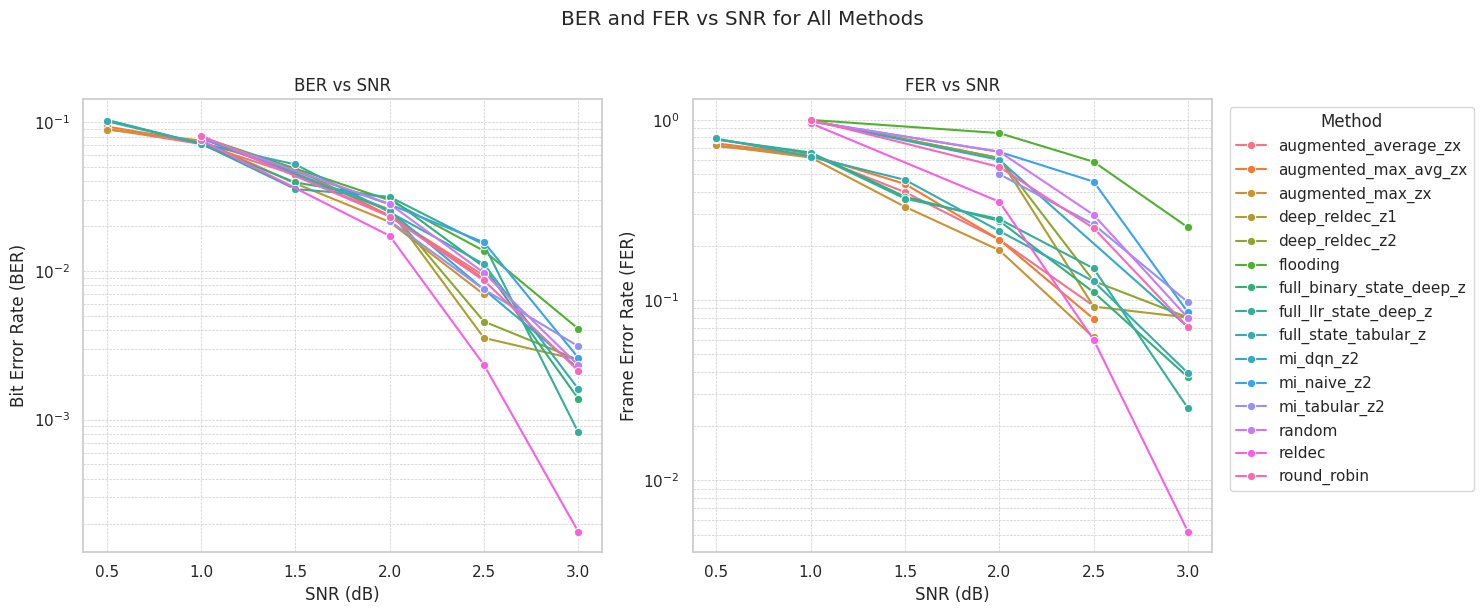

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

sns.lineplot(data=df, x='snr_db', y='ber', hue='method', marker='o', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_xlabel('SNR (dB)')
axes[0].set_ylabel('Bit Error Rate (BER)')
axes[0].set_title('BER vs SNR')
axes[0].grid(True, which='both', ls='--', lw=0.5)

sns.lineplot(data=df, x='snr_db', y='fer', hue='method', marker='o', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_xlabel('SNR (dB)')
axes[1].set_ylabel('Frame Error Rate (FER)')
axes[1].set_title('FER vs SNR')
axes[1].grid(True, which='both', ls='--', lw=0.5)

handles, labels = axes[1].get_legend_handles_labels()
axes[0].legend().remove()
axes[1].legend(handles=handles, labels=labels, title='Method', bbox_to_anchor=(1.02, 1), loc='upper left')

fig.suptitle('BER and FER vs SNR for All Methods', y=1.02)
fig.tight_layout()
plt.show()


## 5. Combined BER and FER Plot
This combined figure shows BER and FER side by side for the selected SNR points.

## 6. Plot Average Messages vs SNR for All Methods
Create a line plot comparing the average number of messages vs SNR (dB) for all evaluated methods.

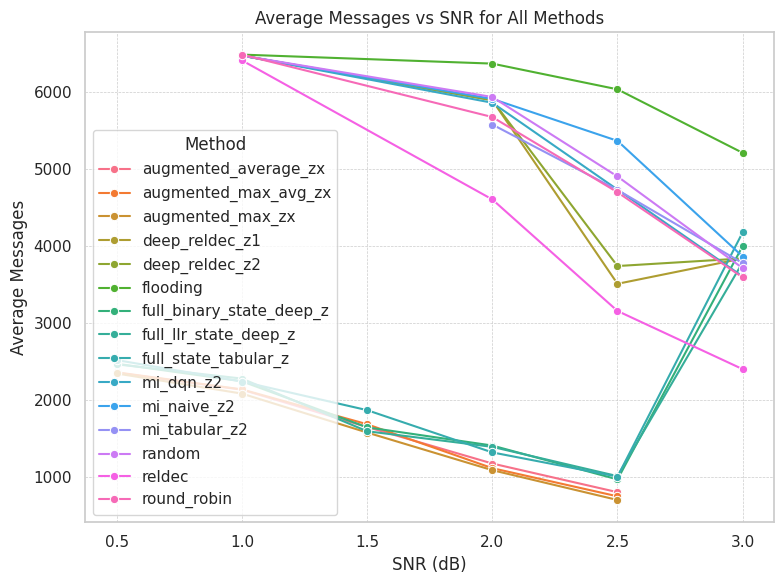

In [5]:
plt.figure(figsize=(8,6))
sns.lineplot(data=df, x='snr_db', y='avg_messages', hue='method', marker='o')
plt.xlabel('SNR (dB)')
plt.ylabel('Average Messages')
plt.title('Average Messages vs SNR for All Methods')
plt.legend(title='Method')
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()


## 8. Average Messages at 2.0/2.5/3.0 dB
Compare message complexity across methods using precomputed results only.

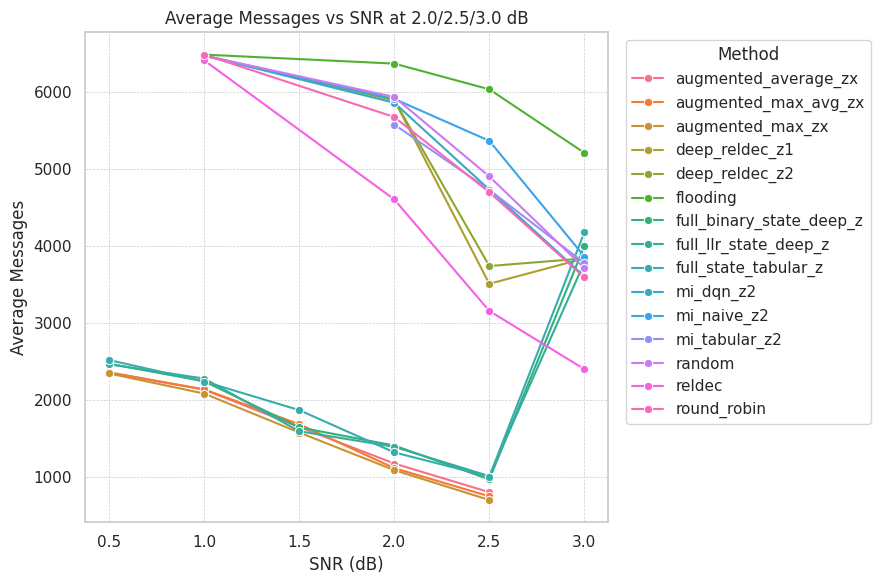

In [6]:
df_messages = df.copy()

if df_messages.empty:
    print('No rows found for the selected SNR points [2.0, 2.5, 3.0].')
else:
    plt.figure(figsize=(9, 6))
    sns.lineplot(
        data=df_messages.sort_values(['method', 'snr_db']),
        x='snr_db',
        y='avg_messages',
        hue='method',
        marker='o',
    )
    plt.xlabel('SNR (dB)')
    plt.ylabel('Average Messages')
    plt.title('Average Messages vs SNR at 2.0/2.5/3.0 dB')
    plt.grid(True, which='both', ls='--', lw=0.5)
    plt.legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


In [7]:
# Filter the dataframe to feature only Flooding, RELDEC, Random, and all mi related plots
allowed_methods = ['flooding', 'reldec', 'deep_reldec_z1', 'deep_reldec_z2', 'random', 'mi_naive_z2', 'mi_dqn_z2', 'mi_tabular_z2']
df = df[df['method'].isin(allowed_methods)].copy()
print('Filtered dataframe methods:', df['method'].unique())


Filtered dataframe methods: ['deep_reldec_z1' 'deep_reldec_z2' 'flooding' 'mi_dqn_z2' 'mi_naive_z2'
 'mi_tabular_z2' 'random' 'reldec']


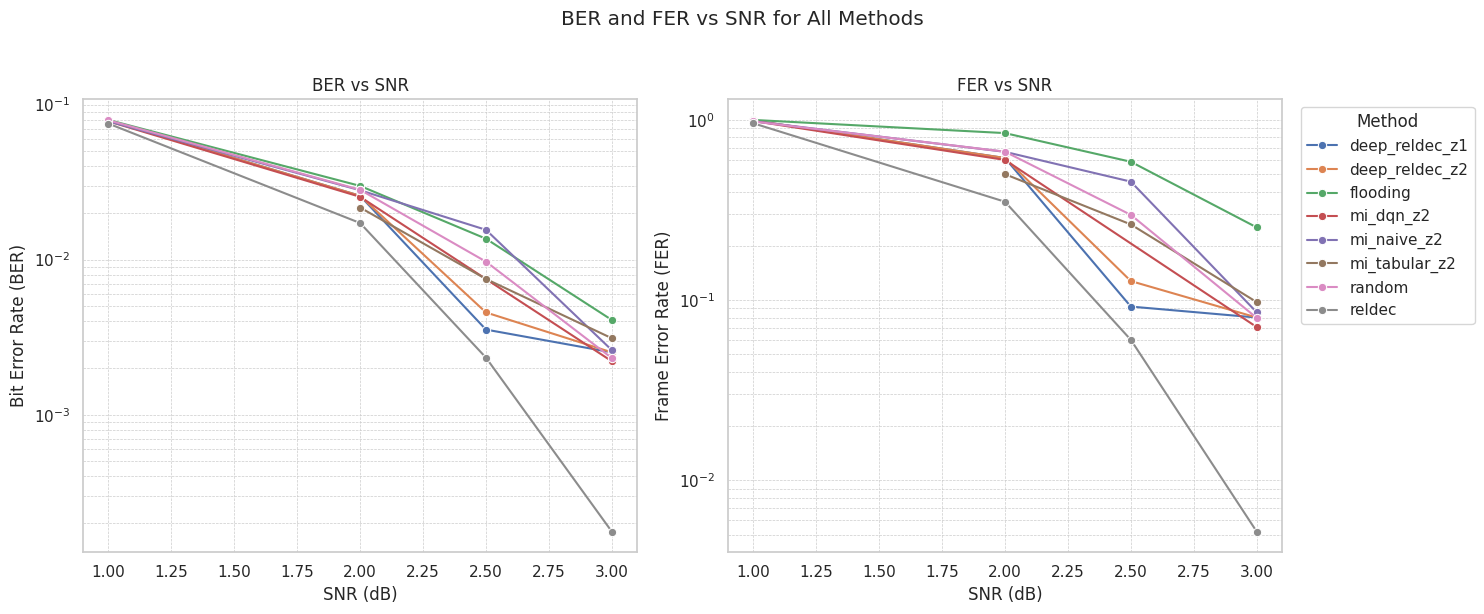

In [8]:
# Subset BER Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

sns.lineplot(data=df, x='snr_db', y='ber', hue='method', marker='o', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_xlabel('SNR (dB)')
axes[0].set_ylabel('Bit Error Rate (BER)')
axes[0].set_title('BER vs SNR')
axes[0].grid(True, which='both', ls='--', lw=0.5)

sns.lineplot(data=df, x='snr_db', y='fer', hue='method', marker='o', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_xlabel('SNR (dB)')
axes[1].set_ylabel('Frame Error Rate (FER)')
axes[1].set_title('FER vs SNR')
axes[1].grid(True, which='both', ls='--', lw=0.5)

handles, labels = axes[1].get_legend_handles_labels()
axes[0].legend().remove()
axes[1].legend(handles=handles, labels=labels, title='Method', bbox_to_anchor=(1.02, 1), loc='upper left')

fig.suptitle('BER and FER vs SNR for All Methods', y=1.02)
fig.tight_layout()
plt.show()


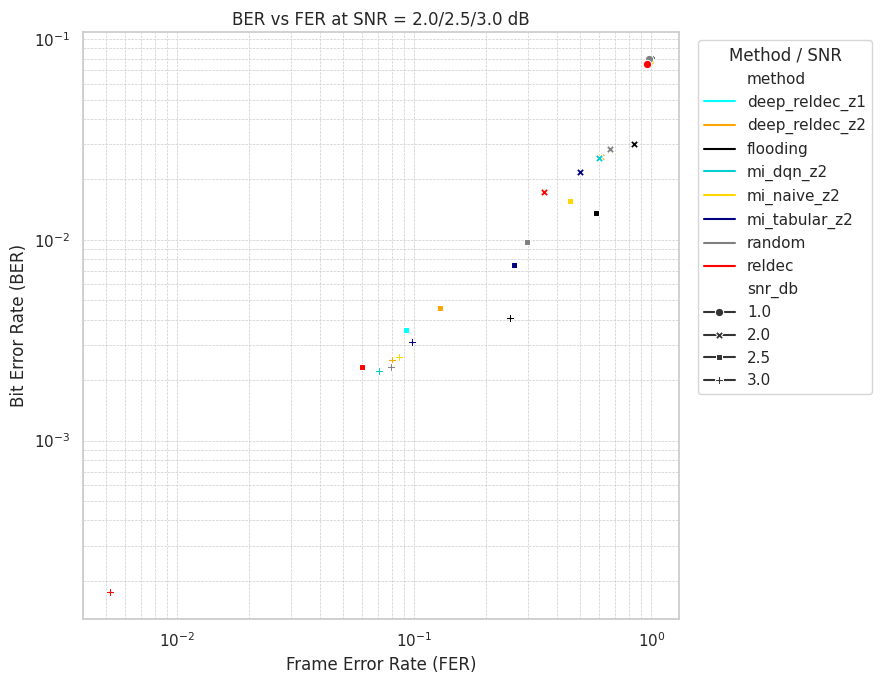

In [9]:
# Subset BER Plot
# Reuse the same color palette
color_palette = {
    'flooding': '#000000',
    'random': '#808080',
    'round_robin': '#8B4513',
    'reldec': '#FF0000',
    'full_state_tabular_z': '#00FF00',
    'full_binary_state_deep_z': '#0000FF',
    'full_llr_state_deep_z': '#FF00FF',
    'deep_reldec_z1': '#00FFFF',
    'deep_reldec_z2': '#FFA500',
    'deep_reldec_zx': '#800080',
    'mi_naive_z2': '#FFD700',
    'mi_naive_zx': '#008000',
    'mi_tabular_z2': '#000080',
    'mi_tabular_zx': '#FF1493',
    'mi_dqn_z2': '#00CED1',
    'mi_dqn_zx': '#8B0000',
    'augmented_max_avg_zx': '#A52A2A',
    'augmented_max_zx': '#5F9EA0',
    'augmented_average_zx': '#7FFF00',
}





selected_snr = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
df_ber_fer = df[df['snr_db'].isin(selected_snr)].copy()

if df_ber_fer.empty:
    print('No rows found for SNR in [2.0, 2.5, 3.0].')
else:
    plt.figure(figsize=(9, 7))
    sns.lineplot(
        data=df_ber_fer.sort_values(['method', 'snr_db']),
        x='fer',
        y='ber',
        hue='method',
        style='snr_db',
        markers=True,
        dashes=False,
        palette=color_palette,
    )
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Frame Error Rate (FER)')
    plt.ylabel('Bit Error Rate (BER)')
    plt.title('BER vs FER at SNR = 2.0/2.5/3.0 dB')
    plt.grid(True, which='both', ls='--', lw=0.5)
    plt.legend(title='Method / SNR', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


Loaded WRAN CSVs: 63
Loaded Mackay CSVs: 14
WRAN methods: ['deep_reldec_z1', 'deep_reldec_z2', 'flooding', 'full_binary_state_deep_z', 'full_llr_state_deep_z', 'full_state_ppo_gnn_z', 'full_state_tabular_z', 'mi_naive_z2', 'mi_tabular_z2', 'random', 'reldec', 'round_robin']
Mackay methods: ['augmented_average_zx', 'augmented_max_avg_zx', 'augmented_max_zx', 'deep_reldec_zx', 'flooding', 'full_binary_state_deep_z', 'full_llr_state_deep_z', 'full_state_ppo_gnn_z', 'full_state_tabular_z', 'mi_dqn_zx', 'mi_naive_zx', 'mi_tabular_zx', 'random', 'reldec', 'round_robin']


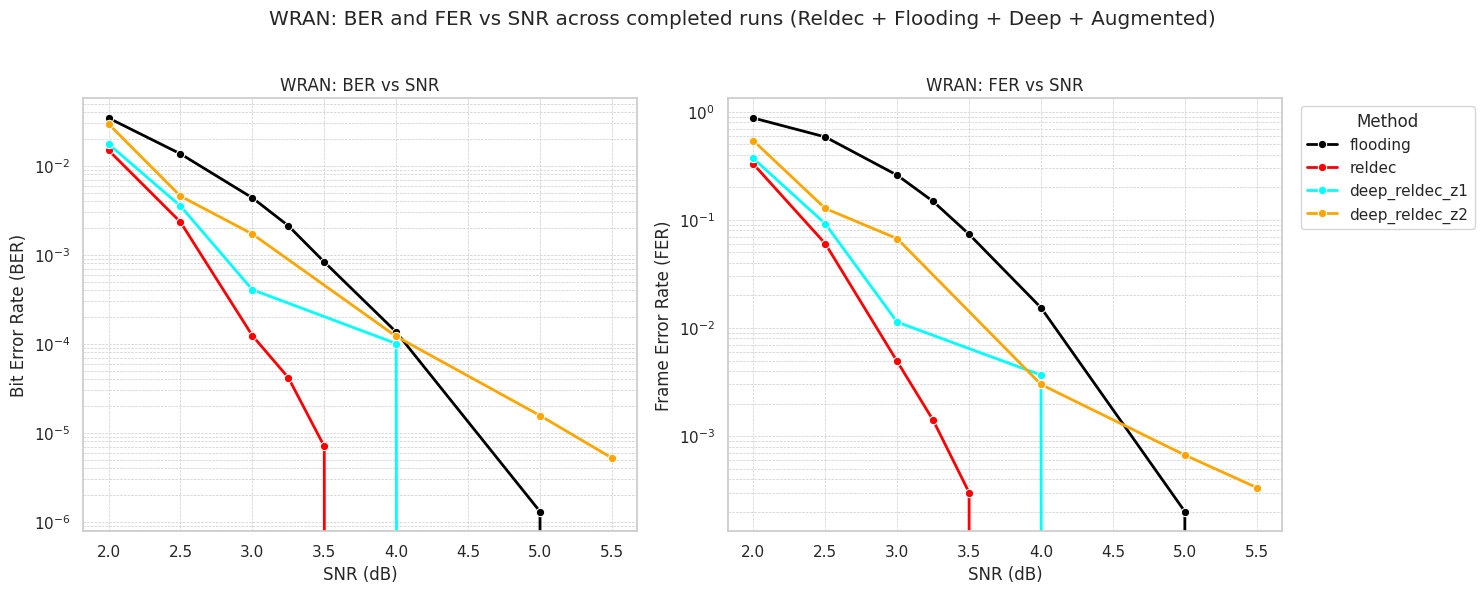

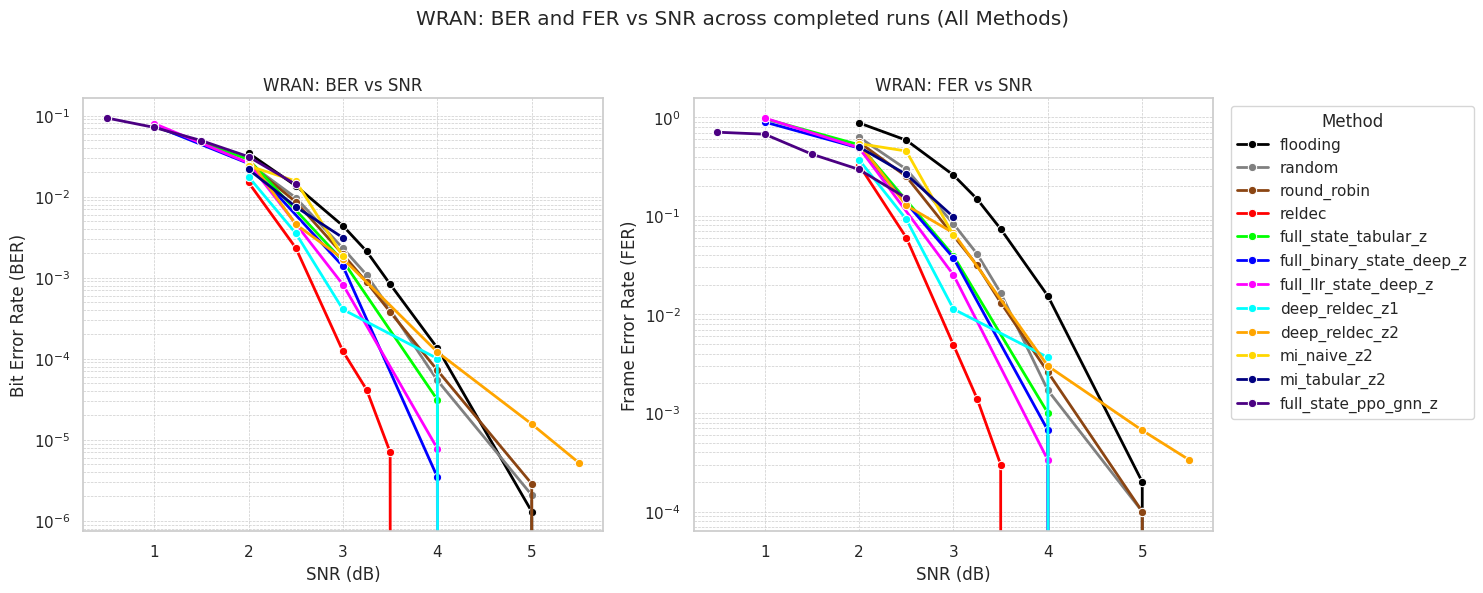

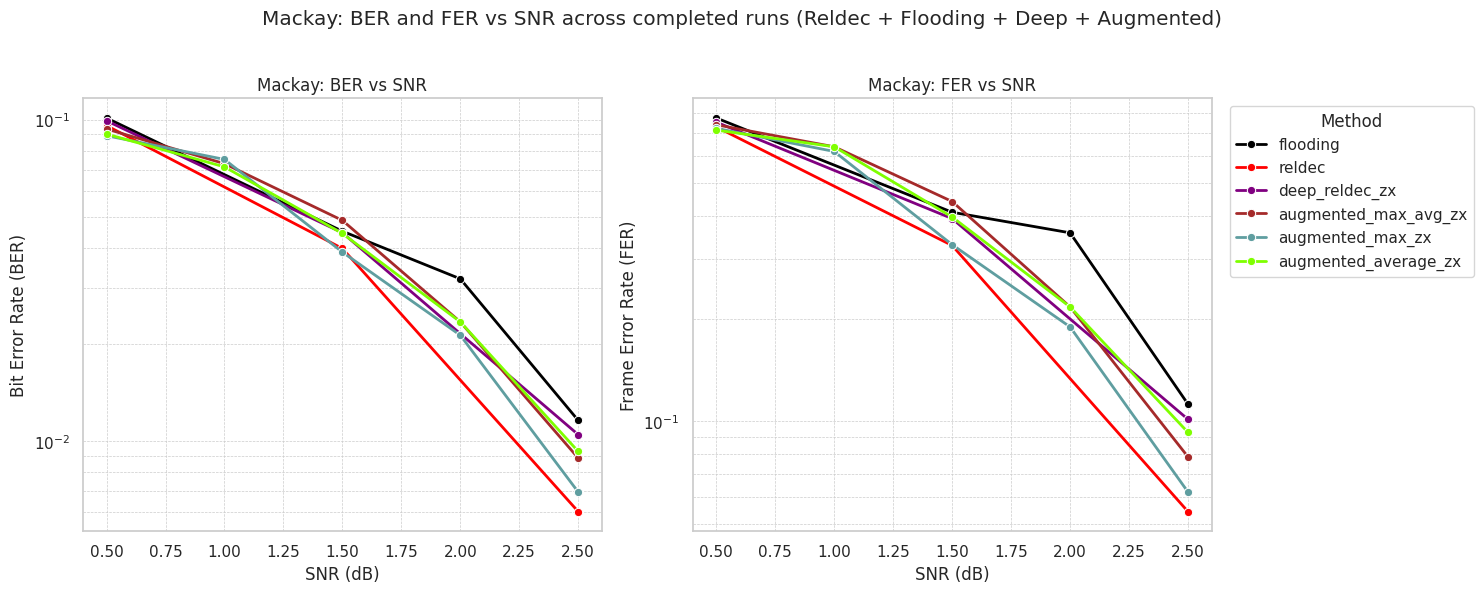

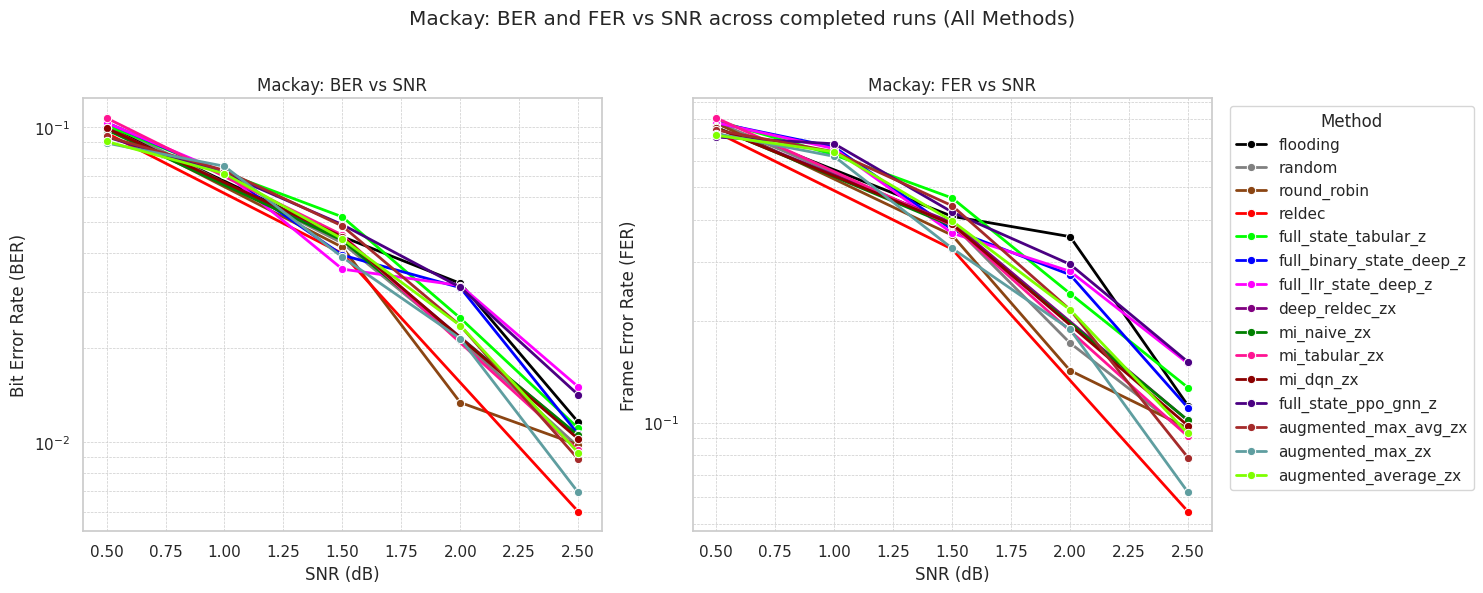

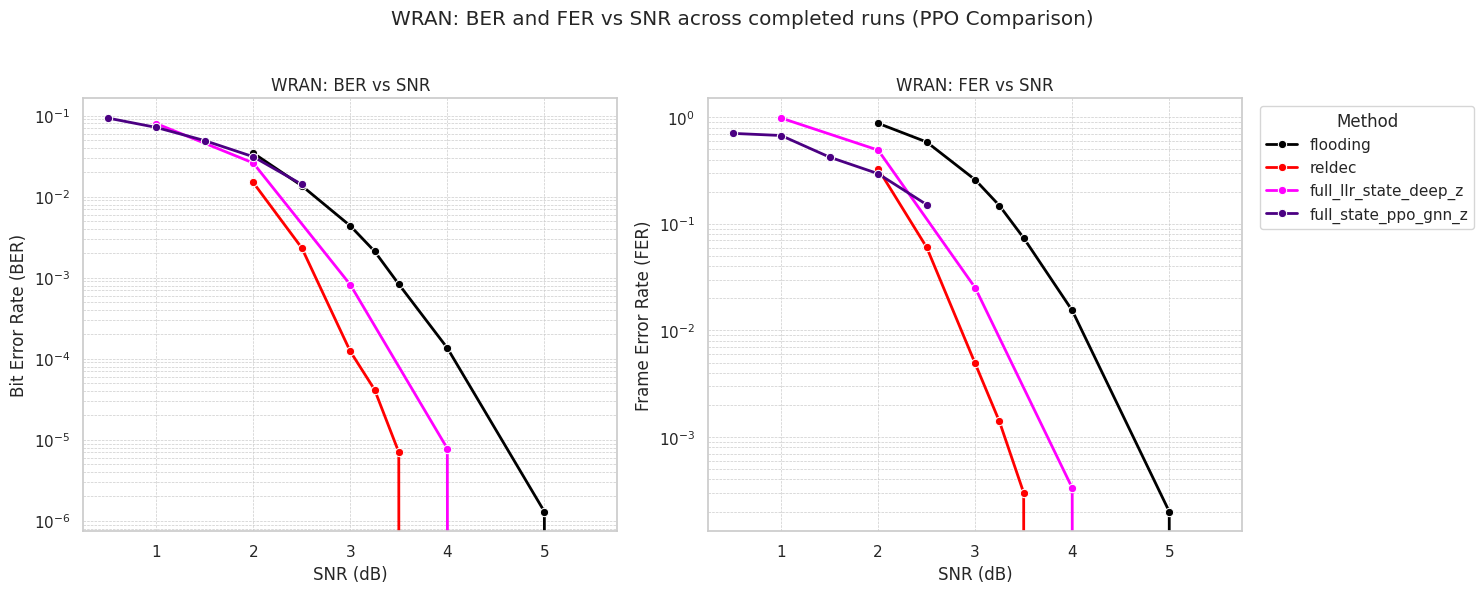

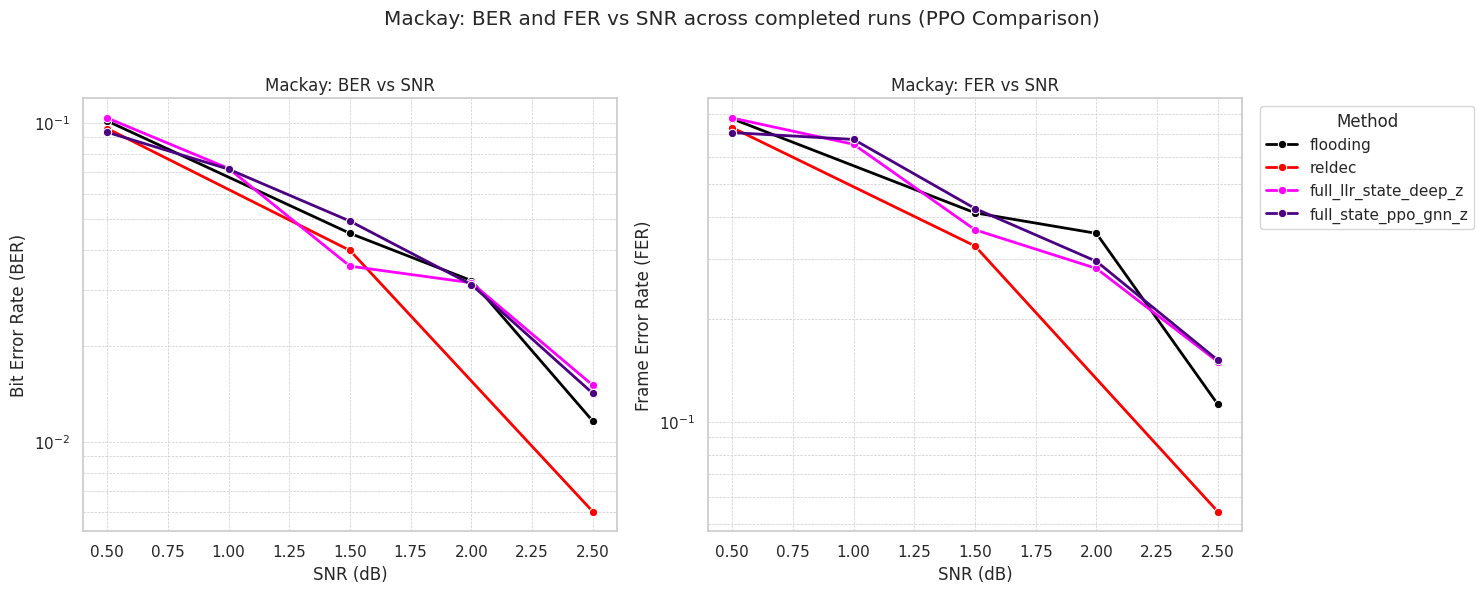

In [10]:
RESULT_SOURCES = {
    'WRAN': [
        ROOT / 'results/eval_global_mdp_full_state_tabular_z_wran.csv',
        ROOT / 'results/eval_global_mdp_full_binary_state_deep_z_wran.csv',
        ROOT / 'results/eval_global_mdp_full_llr_state_deep_z_wran.csv',
        ROOT / 'notebook_runs/continuous_reldec/active_run/wran/results',
    ],
    'Mackay': [
        ROOT / 'results/eval_1000ep_aug_average.csv',
        ROOT / 'results/eval_1000ep_aug_max.csv',
        ROOT / 'results/eval_1000ep_aug_max_avg.csv',
        ROOT / 'results/eval_mackay_baselines_10.csv',
        ROOT / 'results/eval_mackay_reldec_10.csv',
        ROOT / 'results/eval_mackay_mi_tabular_10.csv',
        ROOT / 'results/eval_mackay_mi_naive_10.csv',
        ROOT / 'results/eval_mackay_mi_dqn_10.csv',
        ROOT / 'results/eval_mackay_deep_reldec_10.csv',
        ROOT / 'results/eval_global_mdp_ppo_gnn_mackay.csv',
    ]
}

PLOT_METHOD_ORDER = ['flooding', 'random', 'round_robin', 'reldec', 'deep_reldec_zx', 'mi_naive_zx', 'mi_tabular_zx', 'mi_dqn_zx', 'full_state_ppo_gnn_z', 'augmented_average_zx', 'augmented_max_zx', 'augmented_max_avg_zx']

COLOR_PALETTE = {
    'flooding': 'gray',
    'random': 'silver',
    'round_robin': 'lightgray',
    'reldec': 'blue',
    'deep_reldec_zx': 'cyan',
    'mi_naive_zx': 'green',
    'mi_tabular_zx': 'lime',
    'mi_dqn_zx': 'darkgreen',
    'full_state_ppo_gnn_z': 'purple',
    'augmented_average_zx': 'red',
    'augmented_max_zx': 'orange',
    'augmented_max_avg_zx': 'brown',
}


Plotting solo curve for full_state_ppo_gnn_z on Mackay...


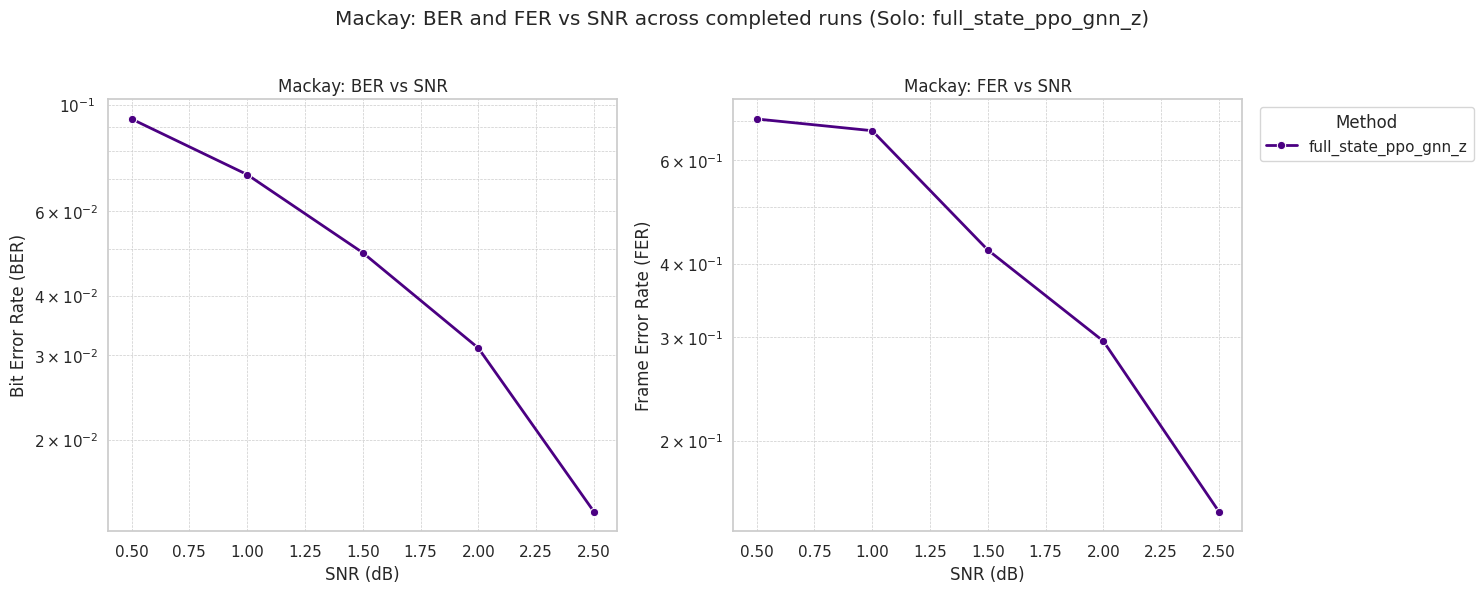

Plotting solo curve for full_state_ppo_gnn_z on WRAN...


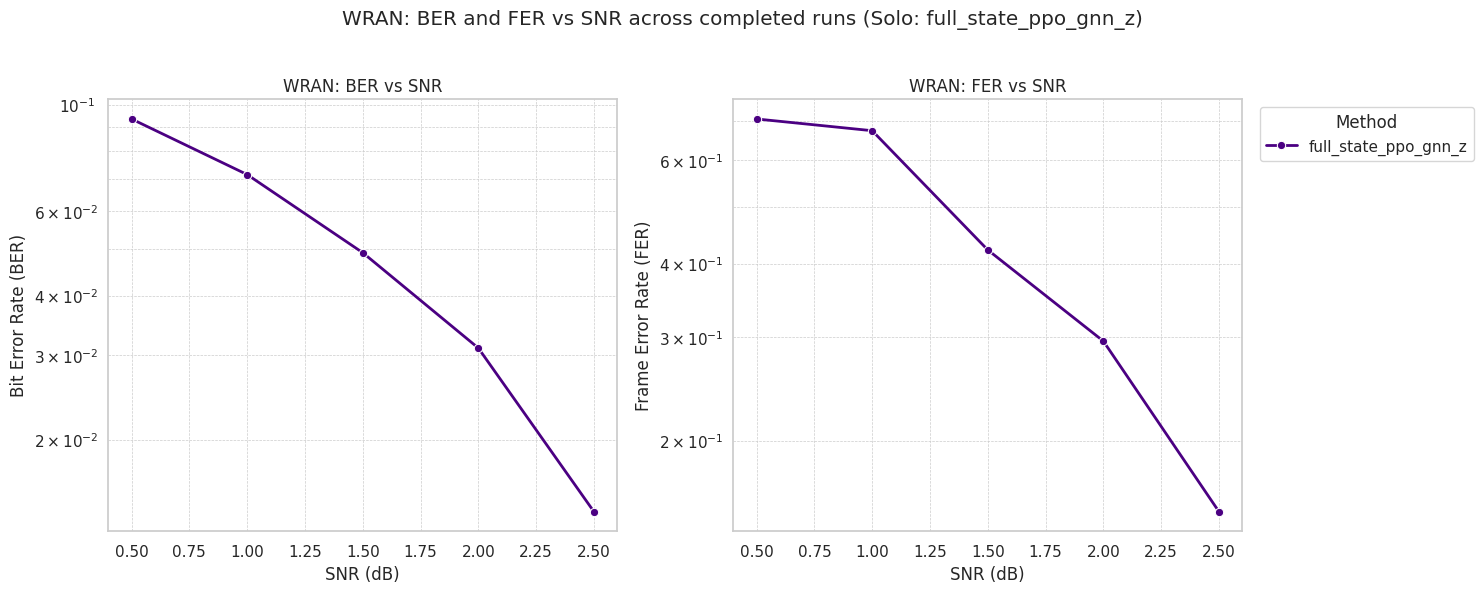

Plotting solo curve for augmented_max_avg_zx on Mackay...


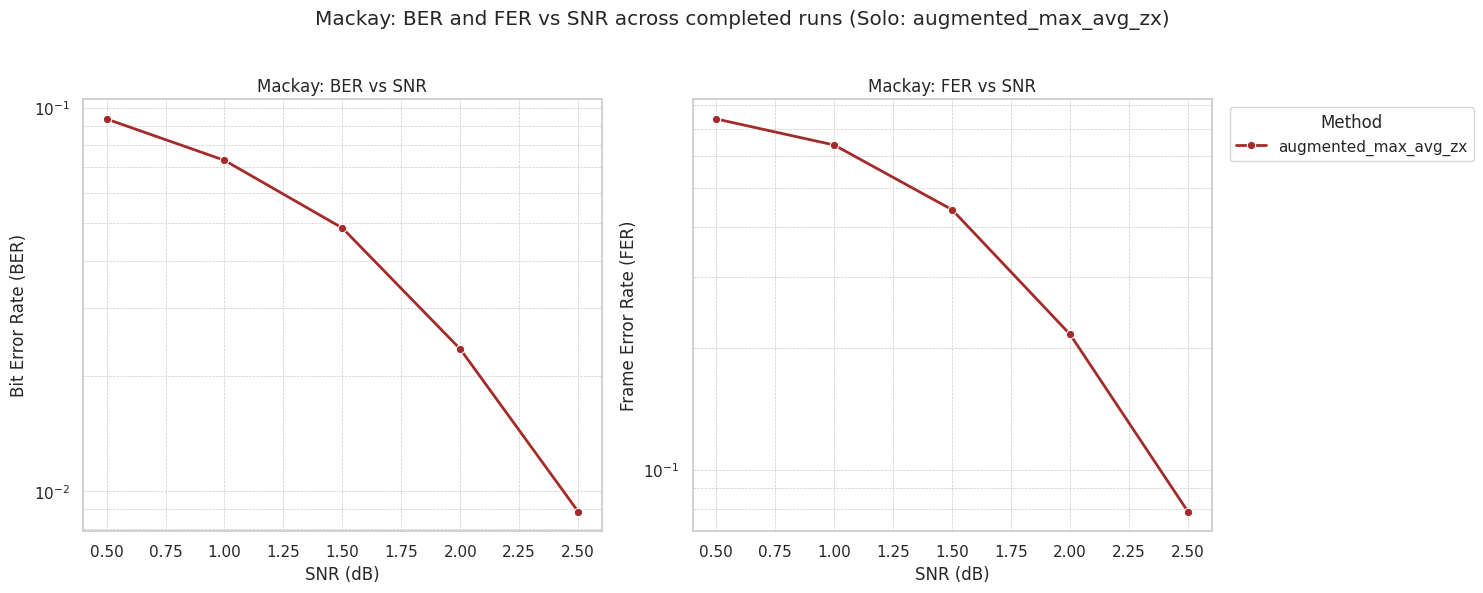

Method augmented_max_avg_zx not found in WRAN data.
Plotting solo curve for augmented_max_zx on Mackay...


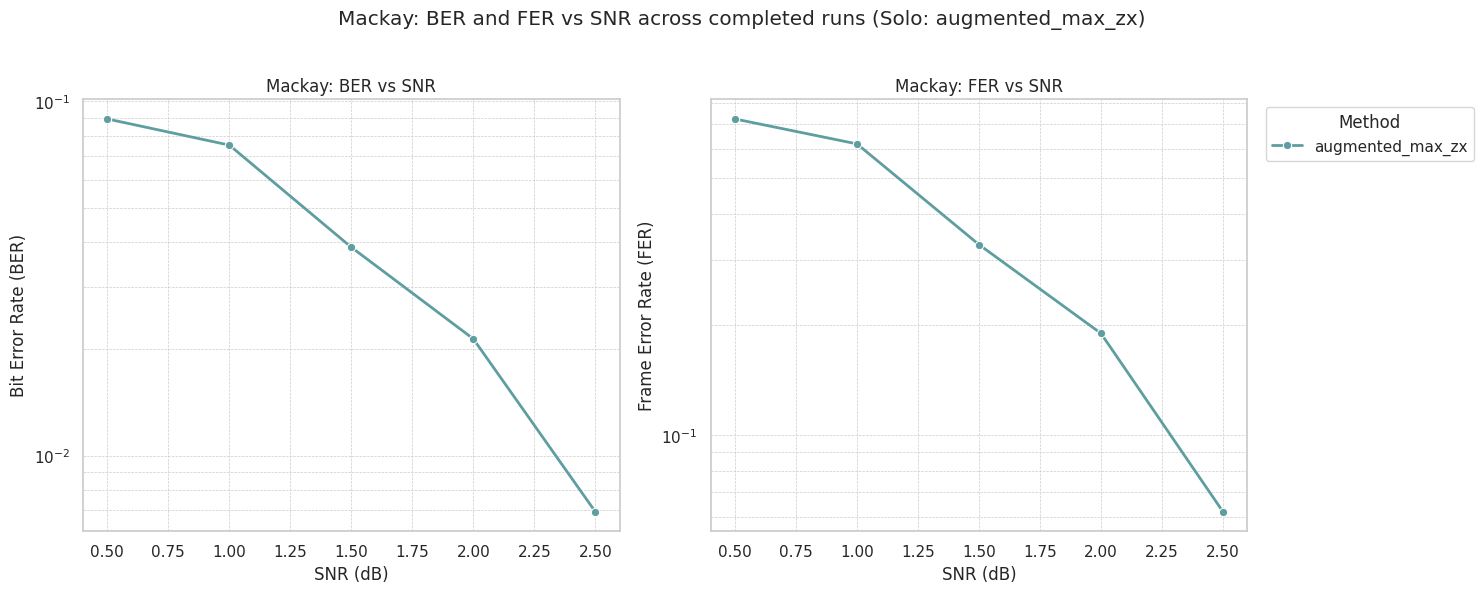

Method augmented_max_zx not found in WRAN data.
Plotting solo curve for augmented_average_zx on Mackay...


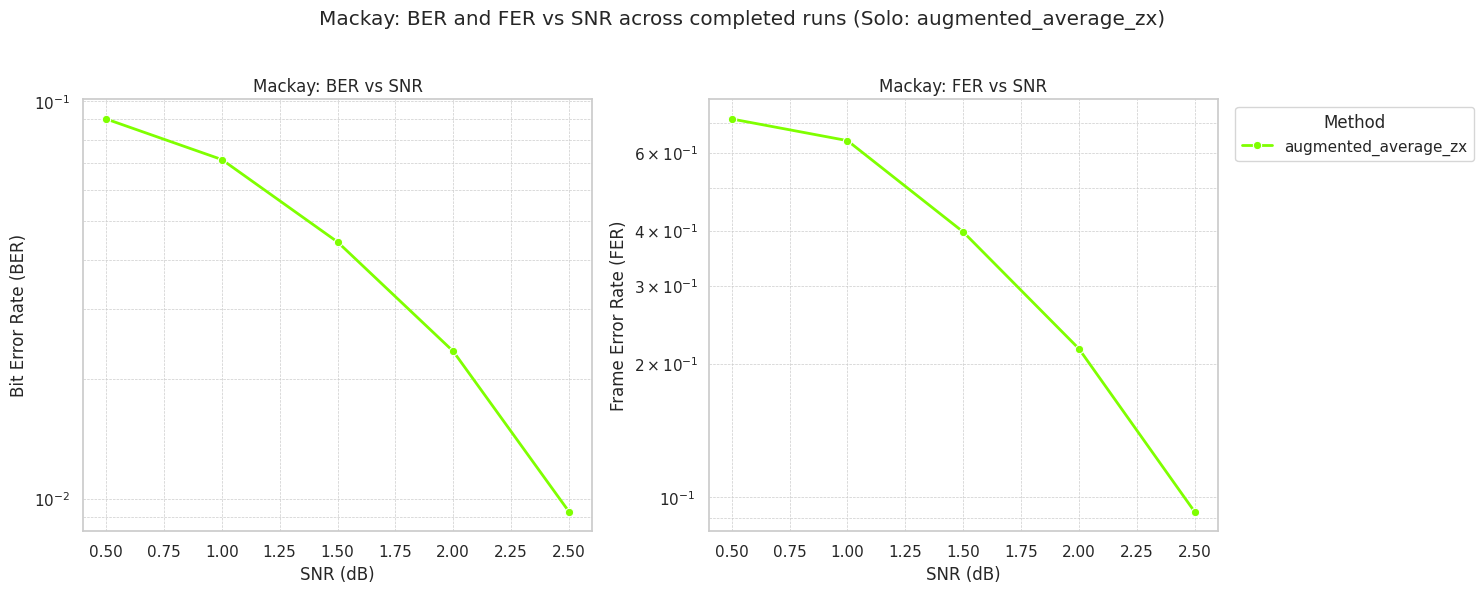

Method augmented_average_zx not found in WRAN data.


In [11]:
methods_to_plot = ['full_state_ppo_gnn_z', 'augmented_max_avg_zx', 'augmented_max_zx', 'augmented_average_zx']

for method in methods_to_plot:
    if method in mackay_df['method'].unique():
        print(f'Plotting solo curve for {method} on Mackay...')
        plot_matrix_curves('Mackay', mackay_df, subset_methods=[method], title_suffix=f'(Solo: {method})')
    else:
        print(f'Method {method} not found in Mackay data.')
        
    if method in wran_df['method'].unique():
        print(f'Plotting solo curve for {method} on WRAN...')
        plot_matrix_curves('WRAN', wran_df, subset_methods=[method], title_suffix=f'(Solo: {method})')
    else:
        print(f'Method {method} not found in WRAN data.')
